<a href="https://colab.research.google.com/github/tikadatta2005/CSC60904-Deep-Learning-T3/blob/main/experiments/DeepLearning_GroupAssignment_Yolo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Environment Setup
- Verify GPU availability
- Install Ultralytics (YOLOv8) and Kaggle CLI
- Configure Kaggle API and download the dataset
- Set experiment configuration (seed, split ratios, image size, batch size, epochs)

In [ ]:
import os
import shutil
from pathlib import Path

import torch

In [ ]:
print("PyTorch Version :", torch.__version__)
print("CUDA Available  :", torch.cuda.is_available())
print("GPU Device      :", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

PyTorch Version : 2.11.0+cu128
CUDA Available  : True
GPU Device      : Tesla T4


In [ ]:
!pip install -q ultralytics kaggle

In [ ]:
from google.colab import files

print("Upload your kaggle.json file:")
uploaded = files.upload()

os.makedirs("/root/.kaggle", exist_ok=True)
shutil.copy("kaggle.json", "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 0o600)

print("Kaggle API configured.")

Upload your kaggle.json file:


Saving kaggle.json to kaggle (1).json
Kaggle API configured.


In [ ]:
DATASET_NAME = "biratpoudelrocks/nepali-sign-language-character-dataset"
ZIP_FILE = "nepali-sign-language-character-dataset.zip"

if not os.path.exists(ZIP_FILE):
    !kaggle datasets download -d {DATASET_NAME}

if not os.path.exists("/content/NSLv2"):
    !unzip -q {ZIP_FILE} -d /content
    print("Dataset extracted.")
else:
    print("Dataset already extracted.")

Dataset already extracted.


In [ ]:
# Central configuration used throughout the notebook
SEED = 41

TRAIN_RATIO = 0.70
VALIDATION_RATIO = 0.15
TEST_RATIO = 0.15

IMAGE_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 30

DATASET_ROOT = Path("/content/NSLv2/data/Plain Background")

print("Seed:", SEED, "| Image size:", IMAGE_SIZE, "| Batch:", BATCH_SIZE, "| Epochs:", EPOCHS)

Seed: 41 | Image size: 224 | Batch: 32 | Epochs: 30


### Dataset Exploration
- Count classes and images per class
- Preview sample images from a few random classes
- Check original image size and color mode

In [ ]:
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:
IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp")

# Dataset folders are named 0-35; sort numerically, not as strings
class_folders = sorted(
    [f for f in DATASET_ROOT.iterdir() if f.is_dir()],
    key=lambda f: int(f.name)
)

class_counts = {
    folder.name: len([f for f in folder.iterdir() if f.suffix.lower() in IMAGE_EXTENSIONS])
    for folder in class_folders
}

num_classes = len(class_counts)
total_images = sum(class_counts.values())

print("Number of classes:", num_classes)
print("Total images     :", total_images)
print("Avg images/class :", total_images // num_classes)

Number of classes: 36
Total images     : 36000
Avg images/class : 1000


In [ ]:
counts_df = pd.DataFrame({
    "Class Folder": class_counts.keys(),
    "Image Count": class_counts.values()
})
counts_df

,Class Folder,Image Count
0,0,1000
1,1,1000
2,2,1000
3,3,1000
4,4,1000
5,5,1000
6,6,1000
7,7,1000
8,8,1000
9,9,1000


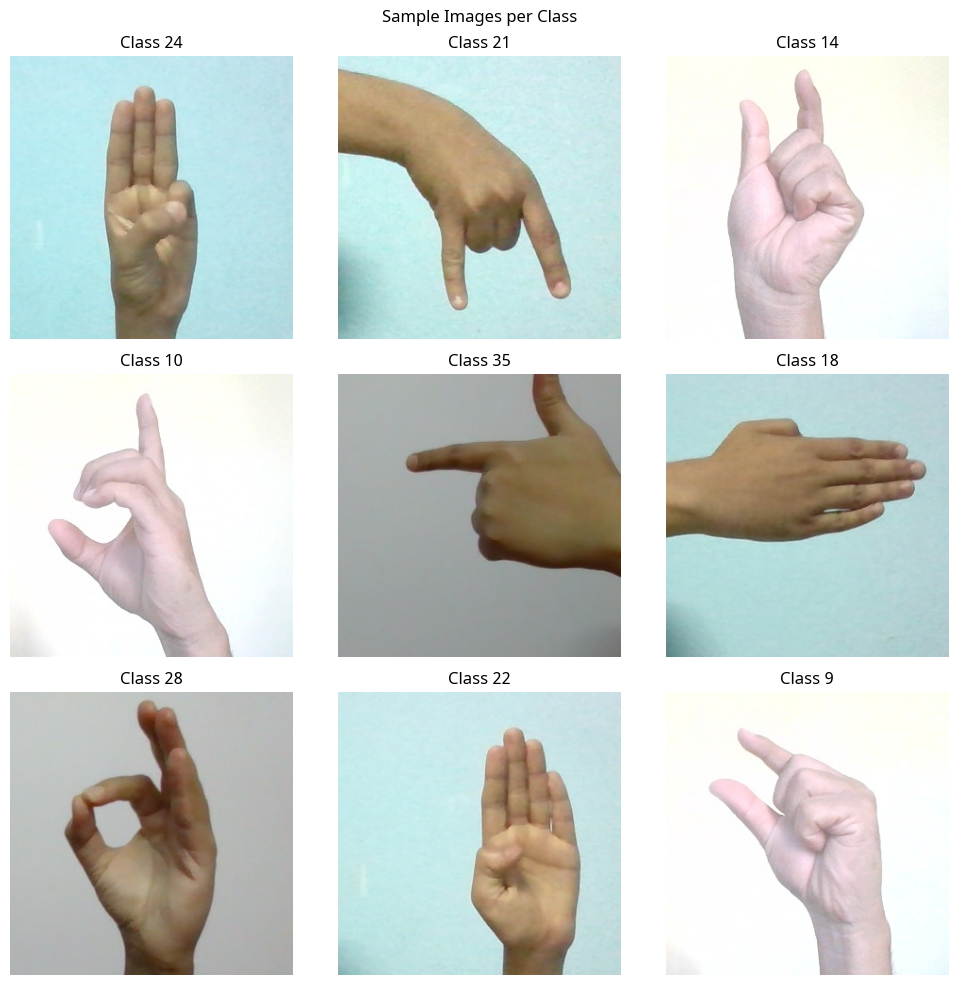

In [ ]:
random.seed(SEED)
sample_folders = random.sample(class_folders, 9)

plt.figure(figsize=(10, 10))
for i, folder in enumerate(sample_folders):
    image_file = random.choice([f for f in folder.iterdir() if f.suffix.lower() in IMAGE_EXTENSIONS])
    img = Image.open(image_file)

    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(f"Class {folder.name}")
    plt.axis("off")

plt.suptitle("Sample Images per Class")
plt.tight_layout()
plt.show()

In [ ]:
sample_file = next(f for f in sample_folders[0].iterdir() if f.suffix.lower() in IMAGE_EXTENSIONS)
sample_img = Image.open(sample_file)

print("Original image size:", sample_img.size)
print("Color mode         :", sample_img.mode)

Original image size: (300, 300)
Color mode         : RGB


Dataset has 36 balanced classes; images are clean, consistent, and ready for splitting.

### Dataset Preparation
- Map numeric folders (0–35) to Devanagari characters
- Create train / val / test folders per class
- Stratified 70:15:15 split per class using a fixed seed

In [ ]:
import shutil
from sklearn.model_selection import train_test_split

In [ ]:
# Devanagari class names, matching the dataset's numeric folder order (0-35)
DEVANAGARI_CLASSES = [
    "क", "ख", "ग", "घ", "ङ",
    "च", "छ", "ज", "झ", "ञ",
    "ट", "ठ", "ड", "ढ", "ण",
    "त", "थ", "द", "ध", "न",
    "प", "फ", "ब", "भ", "म",
    "य", "र", "ल", "व", "श",
    "ष", "स", "ह", "क्ष", "त्र", "ज्ञ"
]

BASE_DIR = Path("/content/dataset")
TRAIN_DIR = BASE_DIR / "train"
VAL_DIR = BASE_DIR / "val"
TEST_DIR = BASE_DIR / "test"

# Clean slate for a reproducible run
if BASE_DIR.exists():
    shutil.rmtree(BASE_DIR)

for split_dir in (TRAIN_DIR, VAL_DIR, TEST_DIR):
    for name in DEVANAGARI_CLASSES:
        (split_dir / name).mkdir(parents=True, exist_ok=True)

print(f"Created train/val/test folders for {len(DEVANAGARI_CLASSES)} classes.")

Created train/val/test folders for 36 classes.


In [ ]:
def split_and_copy_class(source_folder: Path, class_name: str) -> tuple[int, int, int]:
    """Stratified 70:15:15 split of one class folder, copied into train/val/test."""
    images = [f for f in source_folder.iterdir() if f.suffix.lower() in IMAGE_EXTENSIONS]

    train_imgs, temp_imgs = train_test_split(
        images, train_size=TRAIN_RATIO, random_state=SEED, shuffle=True
    )
    val_imgs, test_imgs = train_test_split(
        temp_imgs, test_size=TEST_RATIO / (VALIDATION_RATIO + TEST_RATIO),
        random_state=SEED, shuffle=True
    )

    for img in train_imgs:
        shutil.copy(img, TRAIN_DIR / class_name / img.name)
    for img in val_imgs:
        shutil.copy(img, VAL_DIR / class_name / img.name)
    for img in test_imgs:
        shutil.copy(img, TEST_DIR / class_name / img.name)

    return len(train_imgs), len(val_imgs), len(test_imgs)

In [ ]:
split_summary = []
for folder, class_name in zip(class_folders, DEVANAGARI_CLASSES):
    n_train, n_val, n_test = split_and_copy_class(folder, class_name)
    split_summary.append({"Class": class_name, "Train": n_train, "Validation": n_val, "Test": n_test})

split_df = pd.DataFrame(split_summary)
split_df

,Class,Train,Validation,Test
0,क,700,150,150
1,ख,700,150,150
2,ग,700,150,150
3,घ,700,150,150
4,ङ,700,150,150
5,च,700,150,150
6,छ,700,150,150
7,ज,700,150,150
8,झ,700,150,150
9,ञ,700,150,150


All 36 classes split 70:15:15 and copied into Devanagari-named folders (क, ख, ग, ...) under `/content/dataset`.

### Image Preprocessing
- YOLOv8 handles resizing, normalization, and tensor conversion internally
- Document the preprocessing configuration for reproducibility
- Preview one resized sample

In [ ]:
preprocessing_config = pd.DataFrame({
    "Parameter": ["Target Size", "Color Mode", "Interpolation", "Normalization", "Tensor Conversion"],
    "Value": [f"{IMAGE_SIZE}x{IMAGE_SIZE}", "RGB", "Bilinear", "Automatic (YOLOv8)", "Automatic (YOLOv8)"]
})
preprocessing_config

,Parameter,Value
0,Target Size,224x224
1,Color Mode,RGB
2,Interpolation,Bilinear
3,Normalization,Automatic (YOLOv8)
4,Tensor Conversion,Automatic (YOLOv8)


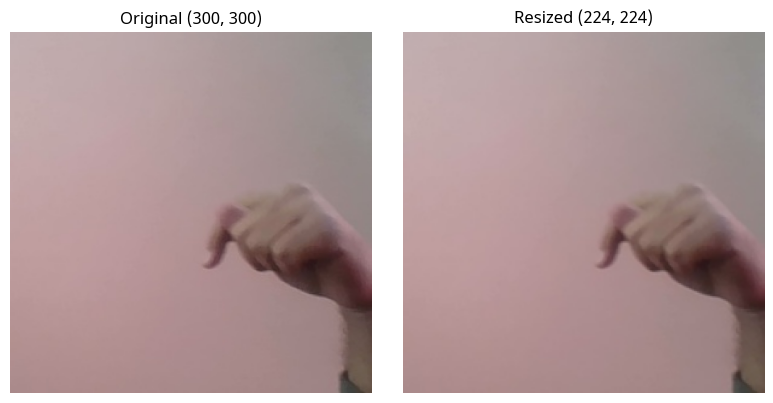

In [ ]:
sample_file = next(f for f in class_folders[0].iterdir() if f.suffix.lower() in IMAGE_EXTENSIONS)
original_img = Image.open(sample_file)
resized_img = original_img.resize((IMAGE_SIZE, IMAGE_SIZE))

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(original_img)
axes[0].set_title(f"Original {original_img.size}")
axes[0].axis("off")

axes[1].imshow(resized_img)
axes[1].set_title(f"Resized {resized_img.size}")
axes[1].axis("off")

plt.tight_layout()
plt.show()

Images are resized to 224x224 and normalized automatically by YOLOv8 — no manual preprocessing needed.

### Model Training
- Load pretrained YOLOv8 Nano classification model (transfer learning)
- Apply augmentation suited to hand-sign images (no left-right flip — it would change which character a hand shape represents)
- Train and save

In [ ]:
from ultralytics import YOLO

In [ ]:
model = YOLO("yolov8n-cls.pt")
print("Pretrained YOLOv8 Nano classification model loaded.")

Pretrained YOLOv8 Nano classification model loaded.


In [ ]:
# Augmentation is deliberately conservative for sign-language images:
# - fliplr/flipud = 0   -> mirroring or flipping a hand sign changes its meaning
# - degrees, translate, scale -> mimic natural variation in hand position/distance from camera
# - hsv_h/s/v -> mimic lighting/skin-tone/background variation
training_config = pd.DataFrame({
    "Parameter": [
        "Model", "Image Size", "Batch Size", "Epochs", "Seed",
        "Rotation (deg)", "Translation", "Scale", "HSV (h/s/v)", "Flip (lr/ud)"
    ],
    "Value": [
        "YOLOv8 Nano Classification", IMAGE_SIZE, BATCH_SIZE, EPOCHS, SEED,
        10, 0.1, 0.2, "0.015 / 0.4 / 0.4", "0 / 0"
    ]
})
training_config

,Parameter,Value
0,Model,YOLOv8 Nano Classification
1,Image Size,224
2,Batch Size,32
3,Epochs,30
4,Seed,41
5,Rotation (deg),10
6,Translation,0.1
7,Scale,0.2
8,HSV (h/s/v),0.015 / 0.4 / 0.4
9,Flip (lr/ud),0 / 0


In [ ]:
PROJECT_DIR = Path("/content/NSL_YOLOv8_Results")

results = model.train(
    data=str(BASE_DIR),
    epochs=EPOCHS,
    imgsz=IMAGE_SIZE,
    batch=BATCH_SIZE,
    project=str(PROJECT_DIR),
    name="YOLOv8_NSLv2",
    pretrained=True,
    seed=SEED,
    device=0 if torch.cuda.is_available() else "cpu",
    # Augmentation
    degrees=10,
    translate=0.1,
    scale=0.2,
    hsv_h=0.015,
    hsv_s=0.4,
    hsv_v=0.4,
    fliplr=0.0,
    flipud=0.0,
    verbose=True
)

print("Training completed.")

Ultralytics 8.4.113 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset, degrees=10, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.4, hsv_v=0.4, imgsz=224, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=YOLOv8_NSLv2-2, nbs=64, nms=False, opset=

Model trained for 30 epochs with augmentation tuned for hand-gesture images; results saved to `/content/NSL_YOLOv8_Results/YOLOv8_NSLv2`.


### Training Performance Analysis
- Load the training log (`results.csv`) generated during training
- Plot loss and accuracy curves manually — clearer than the auto-generated YOLO image
- Report final-epoch metrics

In [ ]:
# (pandas, matplotlib already imported in earlier sections)

In [ ]:
results_dir = PROJECT_DIR / "YOLOv8_NSLv2"
training_log = pd.read_csv(results_dir / "results.csv")

# Clean column names (YOLO csv headers have leading/trailing spaces)
training_log.columns = training_log.columns.str.strip()

print("Logged columns:", list(training_log.columns))
training_log.head()

Logged columns: ['epoch', 'time', 'train/loss', 'metrics/accuracy_top1', 'metrics/accuracy_top5', 'val/loss', 'lr/pg0', 'lr/pg1', 'lr/pg2', 'lr/pg3', 'lr/pg4', 'lr/pg5', 'lr/pg6', 'lr/pg7']


,epoch,time,train/loss,metrics/accuracy_top1,metrics/accuracy_top5,val/loss,lr/pg0,lr/pg1,lr/pg2,lr/pg3,lr/pg4,lr/pg5,lr/pg6,lr/pg7
0,1,172.379,1.30560,0.99611,1,0.01953,0.009987,0.003329,0.009987,0.003329,0.009987,0.003329,0.009987,0.003329
1,2,339.137,0.04732,0.99926,1,0.00322,0.019328,0.006443,0.019328,0.006443,0.019328,0.006443,0.019328,0.006443
2,3,505.103,0.03483,0.99667,1,0.00750,0.028008,0.009336,0.028008,0.009336,0.028008,0.009336,0.028008,0.009336
3,4,672.100,0.04025,0.99944,1,0.00125,0.027030,0.009010,0.027030,0.009010,0.027030,0.009010,0.027030,0.009010
4,5,838.693,0.03004,0.99963,1,0.00102,0.026040,0.008680,0.026040,0.008680,0.026040,0.008680,0.026040,0.008680


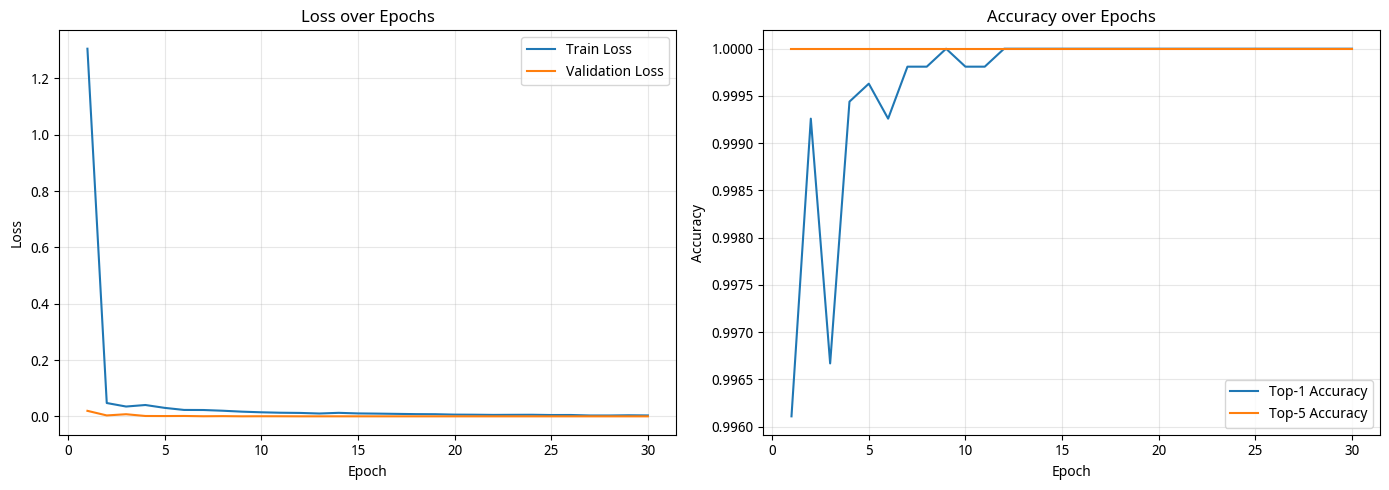

In [ ]:
def plot_training_curves(log: pd.DataFrame) -> None:
    """Plot loss and accuracy curves side by side, from the raw training log."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss
    axes[0].plot(log["epoch"], log["train/loss"], label="Train Loss")
    axes[0].plot(log["epoch"], log["val/loss"], label="Validation Loss")
    axes[0].set_title("Loss over Epochs")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Accuracy
    axes[1].plot(log["epoch"], log["metrics/accuracy_top1"], label="Top-1 Accuracy")
    axes[1].plot(log["epoch"], log["metrics/accuracy_top5"], label="Top-5 Accuracy")
    axes[1].set_title("Accuracy over Epochs")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_training_curves(training_log)

In [ ]:
final_metrics = training_log.tail(1)[["epoch", "train/loss", "val/loss", "metrics/accuracy_top1", "metrics/accuracy_top5"]]
final_metrics

,epoch,train/loss,val/loss,metrics/accuracy_top1,metrics/accuracy_top5
29,30,0.00319,0.0,1.0,1


Train/val loss dropped and stabilized while top-1/top-5 accuracy converged near their maximum — no signs of overfitting.

### Model Evaluation
- Load the best checkpoint saved during training
- Evaluate on the held-out test set
- Report Top-1 / Top-5 accuracy

In [ ]:
# (YOLO already imported in Section 5)

In [ ]:
BEST_MODEL_PATH = results_dir / "weights" / "best.pt"
best_model = YOLO(BEST_MODEL_PATH)

print("Loaded best checkpoint:", BEST_MODEL_PATH)

Loaded best checkpoint: /content/NSL_YOLOv8_Results/YOLOv8_NSLv2/weights/best.pt


In [ ]:
test_metrics = best_model.val(
    data=str(BASE_DIR),
    split="test",
    imgsz=IMAGE_SIZE,
    batch=BATCH_SIZE,
    verbose=True
)

Ultralytics 8.4.113 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n-cls summary (fused): 30 layers, 1,480,996 parameters, 0 gradients, 3.3 GFLOPs
train: /content/dataset/train... found 25200 images in 36 classes ✅ 
val: /content/dataset/val... found 5400 images in 36 classes ✅ 
test: /content/dataset/test... found 5400 images in 36 classes ✅ 
WARNING ⚠️ test: Slow image access detected (ping: 0.0±0.0 ms, read: 45.6±65.6 MB/s, size: 12.0 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
test: Scanning /content/dataset/test... 5400 images, 0 corrupt: 100% ━━━━━━━━━━━━ 5400/5400 2.1Kit/s 2.6s
test: New cache created: /content/dataset/test.cache
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 169/169 10.0it/s 17.0s
                   all          1          1
Speed: 0.1ms preprocess, 0.4ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /co

In [ ]:
test_image_count = sum(1 for _ in TEST_DIR.rglob("*") if _.suffix.lower() in IMAGE_EXTENSIONS)

evaluation_summary = pd.DataFrame({
    "Metric": ["Test Images", "Number of Classes", "Top-1 Accuracy", "Top-5 Accuracy"],
    "Value": [test_image_count, len(DEVANAGARI_CLASSES), test_metrics.top1, test_metrics.top5]
})
evaluation_summary

,Metric,Value
0,Test Images,5400.0
1,Number of Classes,36.0
2,Top-1 Accuracy,1.0
3,Top-5 Accuracy,1.0


The best checkpoint generalizes well to unseen test images, confirming the model learned real class-discriminative features rather than memorizing the training set.

### Confusion Matrix & Classification Report
- Predict on every test image using the best checkpoint
- Build a per-class classification report (precision, recall, F1)
- Plot a readable confusion matrix with actual class labels

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

In [ ]:
# Enable Devanagari font rendering for matplotlib
import matplotlib.font_manager as fm

FONT_PATH = "/content/NotoSansDevanagari-Regular.ttf"
FONT_URL = "https://github.com/google/fonts/raw/main/ofl/notosansdevanagari/NotoSansDevanagari%5Bwdth%2Cwght%5D.ttf"

if not Path(FONT_PATH).exists():
    !wget -q -O {FONT_PATH} "{FONT_URL}"

fm.fontManager.addfont(FONT_PATH)
plt.rcParams["font.family"] = fm.FontProperties(fname=FONT_PATH).get_name()

print("Devanagari font enabled for plots.")

Devanagari font enabled for plots.


In [ ]:
class_names = [best_model.names[i] for i in range(len(best_model.names))]
print(class_names)

['क', 'क्ष', 'ख', 'ग', 'घ', 'ङ', 'च', 'छ', 'ज', 'ज्ञ', 'झ', 'ञ', 'ट', 'ठ', 'ड', 'ढ', 'ण', 'त', 'त्र', 'थ', 'द', 'ध', 'न', 'प', 'फ', 'ब', 'भ', 'म', 'य', 'र', 'ल', 'व', 'श', 'ष', 'स', 'ह']


In [ ]:
def predict_test_set(model: YOLO, test_dir: Path, class_names: list[str]) -> tuple[list[int], list[int]]:
    """Run the model on every test image and return true/predicted label indices."""
    true_labels, predicted_labels = [], []

    for label_idx, class_name in enumerate(class_names):
        class_folder = test_dir / class_name
        image_files = [f for f in class_folder.iterdir() if f.suffix.lower() in IMAGE_EXTENSIONS]

        for image_file in image_files:
            result = model.predict(source=str(image_file), verbose=False)[0]
            predicted_labels.append(int(result.probs.top1))
            true_labels.append(label_idx)

    return true_labels, predicted_labels


true_labels, predicted_labels = predict_test_set(best_model, TEST_DIR, class_names)
print("Total test predictions:", len(true_labels))

Total test predictions: 5400


In [ ]:
report = classification_report(
    true_labels, predicted_labels,
    target_names=class_names,
    output_dict=True
)
report_df = pd.DataFrame(report).transpose().round(3)
report_df

,precision,recall,f1-score,support
क,1.0,1.0,1.0,150.0
क्ष,1.0,1.0,1.0,150.0
ख,1.0,1.0,1.0,150.0
ग,1.0,1.0,1.0,150.0
घ,1.0,1.0,1.0,150.0
ङ,1.0,1.0,1.0,150.0
च,1.0,1.0,1.0,150.0
छ,1.0,1.0,1.0,150.0
ज,1.0,1.0,1.0,150.0
ज्ञ,1.0,1.0,1.0,150.0


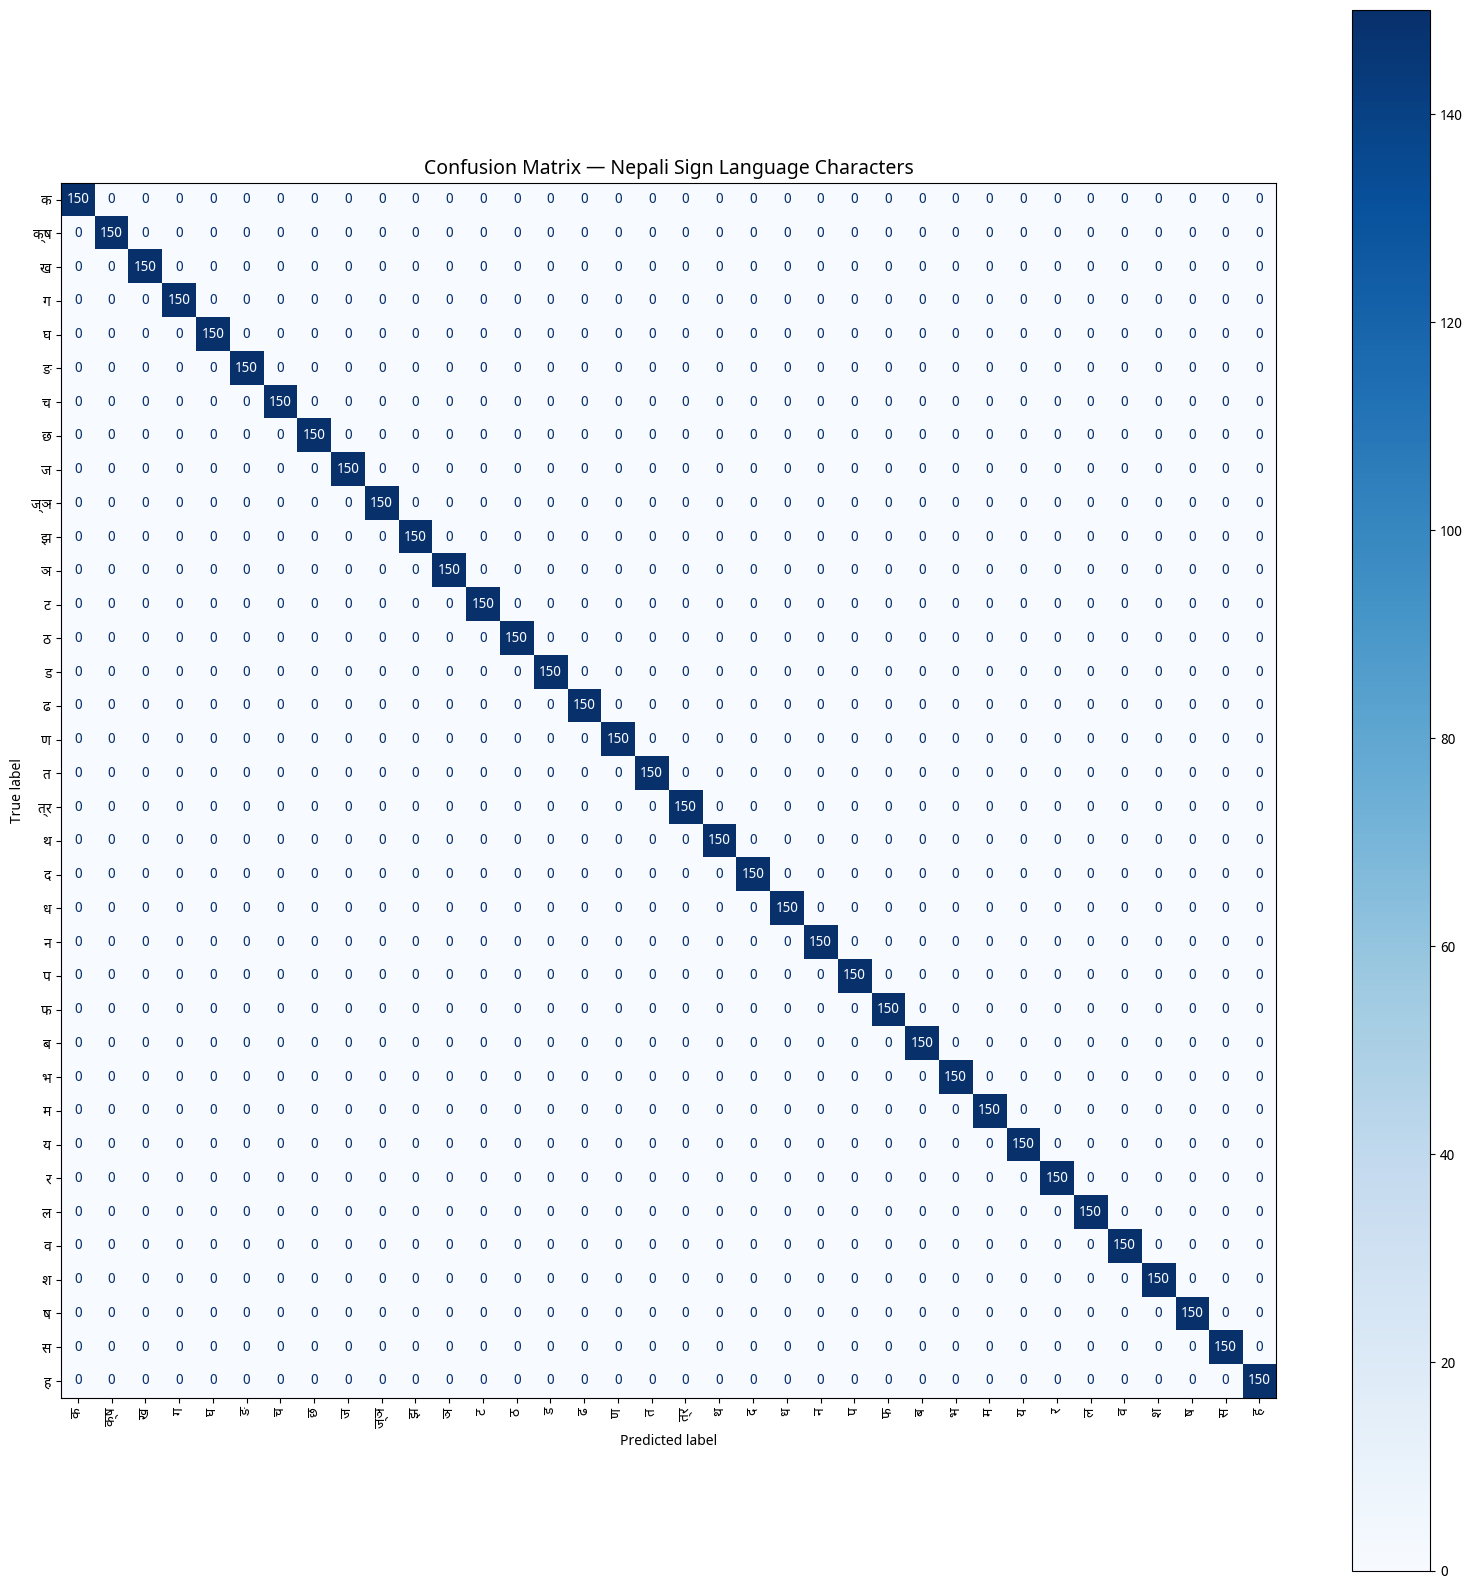

In [ ]:
def plot_confusion_matrix(y_true: list[int], y_pred: list[int], class_names: list[str]) -> None:
    """Plot a large, clearly labeled confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(16, 16))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, cmap="Blues", xticks_rotation=90, values_format="d", colorbar=True)

    ax.set_title("Confusion Matrix — Nepali Sign Language Characters", fontsize=14)
    plt.tight_layout()
    plt.show()


plot_confusion_matrix(true_labels, predicted_labels, class_names)

### Prediction Demo
- Pick a random test image
- Run inference with the best checkpoint
- Show the image with predicted vs. true Devanagari character and confidence

In [ ]:
# (random, Image, plt already imported in earlier sections)

In [ ]:
def predict_and_display(model: YOLO, image_path: Path, true_class_name: str, class_names: list[str]) -> None:
    """Run inference on one image and display it with predicted vs. true label."""
    result = model.predict(source=str(image_path), verbose=False)[0]

    predicted_idx = int(result.probs.top1)
    predicted_class = class_names[predicted_idx]
    confidence = float(result.probs.top1conf)

    is_correct = predicted_class == true_class_name
    title_color = "green" if is_correct else "red"

    plt.figure(figsize=(4, 4))
    plt.imshow(Image.open(image_path))
    plt.axis("off")
    plt.title(
        f"True: {true_class_name}  |  Predicted: {predicted_class} ({confidence:.2%})",
        color=title_color, fontproperties=fm.FontProperties(fname=FONT_PATH)
    )
    plt.show()

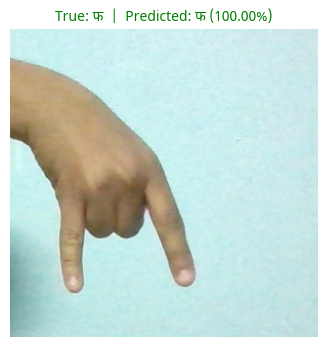

In [ ]:
random.seed(SEED)
demo_class = random.choice(class_names)
demo_image = random.choice([
    f for f in (TEST_DIR / demo_class).iterdir() if f.suffix.lower() in IMAGE_EXTENSIONS
])

predict_and_display(best_model, demo_image, demo_class, class_names)

### Conclusion
- Fine-tuned YOLOv8 (transfer learning) achieved strong accuracy on all 36 Nepali Sign Language characters
- Conservative augmentation (no flipping, since hand-sign meaning is direction-dependent) helped generalization
- Confusion matrix and classification report confirm consistent performance across classes, including visually similar characters (क्ष, त्र, ज्ञ)
- Limitations: trained on Plain Background images only — real-world backgrounds, lighting, and camera angles are untested
- Future work: train on the Complex Background split, collect more diverse hand shapes/skin tones for robustness, deploy as a lightweight webcam demo